# I. Introduction

`Name  : Stefano Veronigo Wijaya`  
  
`Problem Statement: In modern Formula 1, drivers and teams that get a podium will be shown  more to the media which also means that their sponsors also get some of the spotlight
seeing that their race suit and cars are filled with said sponsors. Getting sponsors also means more budget for the team, which also means that they can
better develop the car for the next season and the cycle repeats.`

`Objective: Create a Machine Learning Program that predicts F1 Podiums based on several features where the results can help Teams and Sponsors decide on their next business decision.`

---

# II. Import Libraries

In [2]:
import warnings
warnings.filterwarnings('ignore') # Ignore Warnings
import numpy as np # Numpy
import pandas as pd # Pandas
import matplotlib.pyplot as plt # Visualization
import matplotlib.ticker as mticker # Visualization
import seaborn as sns # Visualization
from scipy.stats import pearsonr # Correlation test
from sklearn.model_selection import train_test_split, cross_validate, RandomizedSearchCV # Train test split, cv, cv again
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Scaler, Encoder
from sklearn.impute import SimpleImputer # Imputer
from sklearn.pipeline import Pipeline # Pipeline
from sklearn.compose import ColumnTransformer # ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier # KNN Model
from sklearn.svm import SVC # SVM Model
from sklearn.tree import DecisionTreeClassifier # DecisionTree Model
from sklearn.ensemble import RandomForestClassifier # RandomForest Model
from xgboost import XGBClassifier # XGBooster Model
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, # Scoring metrics
                             f1_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import joblib # To export
import json # To export

---

# III. Data Loading

Dataset link [here](https://www.kaggle.com/datasets/jtrotman/formula-1-race-data)

Missing value in this dataset is written as `"\\N"`, hence the reason for na_values=`'\\N'`

In [3]:
data_path = "data/"

results = pd.read_csv(data_path + 'results.csv', na_values='\\N')
races = pd.read_csv(data_path + 'races.csv', na_values='\\N')
drivers = pd.read_csv(data_path + 'drivers.csv', na_values='\\N')
qualifying = pd.read_csv(data_path + 'qualifying.csv', na_values='\\N')
driver_standings = pd.read_csv(data_path + 'driver_standings.csv', na_values='\\N')
constructor_standings = pd.read_csv(data_path + 'constructor_standings.csv', na_values='\\N')
constructors = pd.read_csv(data_path + 'constructors.csv', na_values='\\N')
pit_stops = pd.read_csv(data_path + 'pit_stops.csv', na_values='\\N')
status = pd.read_csv(data_path + 'status.csv', na_values='\\N')

name = ["results", "races", "drivers", "qualifying", "driver_standings", "constructor_standings", "constructors", "pit_stops", "status"]
dataframe = [results, races, drivers, qualifying, driver_standings, constructor_standings, constructors, pit_stops, status]

for n, d in zip(name, dataframe):
    print(f"{n}: {d.shape}")

results: (27304, 18)
races: (1171, 18)
drivers: (865, 9)
qualifying: (11036, 9)
driver_standings: (35427, 7)
constructor_standings: (13664, 7)
constructors: (214, 5)
pit_stops: (22193, 7)
status: (140, 2)


Features we will be using are:  
| Index | Feature | Table | Context |
| --- | --- | --- | --- |
| 1 | grid_position | results | Starting grid for the race |
| 2 | quali_position | qualifying | Position in Qualifying Session | 
| 3 | round | races | Race number of the season |  
| 4 | year | races | Season Year |  
| 5 | driver_points_before | driver_standings | Championship points before current race |  
| 6 | driver_position_before | driver_standings | Championship position before current race |  
| 7 | driver_wins_before | driver_standings | Number of wins a driver had before current race |  
| 8 | driver_age | drivers + races | Driver's age (year) in race day |  
| 9 | driver_nationality | drivers | Driver's Nationality |  
| 10 | constructor_nationality | constructors | Constructor's Nationality | 
| 11 | constructor_position_before | constructor_standings | Construction's championship position before current race |  
| 12 | driver_historical_dnf_rate | results + status | DNF rate of the driver from past races |   
| 13 | pit_stops | pit_stops | Number of pit stops done within the race |
| Target | podium | results | Driver finished in one of the top three positions |  

For now, we should attempt to combine all the features into one DataFrame.

In [4]:
df = results[['raceId', 'driverId', 'constructorId', 'grid', 'positionOrder', 'statusId']].copy() # Copy the results DataFrame for further manipulation
df.rename(columns={'grid': 'grid_position'}, inplace=True) # Rename the column for better context

def data_load_info(df):
    '''
    Prints out DataFrame shape and shows first and last 5 data
    '''
    print(f"Base dataframe shape: {df.shape}")
    print("Current First 5 Data")
    display(df.head(5))
    print("Current Last 5 Data")
    display(df.tail(5))

data_load_info(df)

Base dataframe shape: (27304, 6)
Current First 5 Data


,raceId,driverId,constructorId,grid_position,positionOrder,statusId
0,18,1,1,1.0,1,1
1,18,2,2,5.0,2,1
2,18,3,3,7.0,3,1
3,18,4,4,11.0,4,1
4,18,5,1,3.0,5,1


Current Last 5 Data


,raceId,driverId,constructorId,grid_position,positionOrder,statusId
27299,1171,4,117,21.0,18,11
27300,1171,822,216,20.0,19,11
27301,1171,848,3,17.0,20,12
27302,1171,840,117,22.0,21,34
27303,1171,860,210,18.0,22,3


In [5]:
drivers_renamed = drivers[['driverId', 'dob', 'nationality']].rename(columns={'nationality': 'driver_nationality'})
constructors_renamed = constructors[['constructorId', 'nationality']].rename(columns={'nationality': 'constructor_nationality'})
df = df.merge(races[['raceId', 'year', 'round', 'date']],on = 'raceId',how = 'left') # Add year, round, and race date (date is needed to compute driver age), Match rows where raceId is the same, keep data from left (df) and bring matching data from right (races)
df = df.merge(drivers_renamed[['driverId', 'dob', 'driver_nationality']], on='driverId', how='left') # Driver Info, Match rows on driverId
df = df.merge(constructors_renamed[['constructorId', 'constructor_nationality']], on='constructorId', how='left') # Constructor Info, Match rows on constructorId
df = df.merge(qualifying[['raceId', 'driverId', 'position']], on=['raceId','driverId'], how='left') # Qualifying Info, Match rows on both raceId and driverId 
data_load_info(df)

Base dataframe shape: (27304, 13)
Current First 5 Data


,raceId,driverId,constructorId,grid_position,positionOrder,statusId,year,round,date,dob,driver_nationality,constructor_nationality,position
0,18,1,1,1.0,1,1,2008,1,2008-03-16,1985-01-07,British,British,1.0
1,18,2,2,5.0,2,1,2008,1,2008-03-16,1977-05-10,German,German,5.0
2,18,3,3,7.0,3,1,2008,1,2008-03-16,1985-06-27,German,British,7.0
3,18,4,4,11.0,4,1,2008,1,2008-03-16,1981-07-29,Spanish,French,12.0
4,18,5,1,3.0,5,1,2008,1,2008-03-16,1981-10-19,Finnish,British,3.0


Current Last 5 Data


,raceId,driverId,constructorId,grid_position,positionOrder,statusId,year,round,date,dob,driver_nationality,constructor_nationality,position
27299,1171,4,117,21.0,18,11,2026,3,2026-03-29,1981-07-29,Spanish,British,21.0
27300,1171,822,216,20.0,19,11,2026,3,2026-03-29,1989-08-28,Finnish,American,20.0
27301,1171,848,3,17.0,20,12,2026,3,2026-03-29,1996-03-23,Thai,British,17.0
27302,1171,840,117,22.0,21,34,2026,3,2026-03-29,1998-10-29,Canadian,British,22.0
27303,1171,860,210,18.0,22,3,2026,3,2026-03-29,2005-05-08,British,American,18.0


Now we try to complete the base DataFrame

Driver and Constructor Standings.

In [6]:
driver_standings['driver_points_before'] = (driver_standings.groupby('driverId')['points'].shift(1)) # Group data by driverId, focus on points column, move values down by 1 row (for data BEFORE the race)
driver_standings['driver_position_before'] = (driver_standings.groupby('driverId')['position'].shift(1)) # Focuses on position before the race
constructor_standings['constructor_position_before'] = (constructor_standings.groupby('constructorId')['position'].shift(1)) 
#We did not use constructor points to reduce the amount of feature used in this Machine Learning Model, I personally think that Constructor's standing can give enough context about their performance.
df = df.merge(driver_standings[['raceId', 'driverId', 'driver_points_before', 'driver_position_before']],on=['raceId', 'driverId'],how='left')
df = df.merge(constructor_standings[['raceId', 'constructorId', 'constructor_position_before']],on=['raceId', 'constructorId'],how='left')
df['driver_position_before'] = df['driver_position_before'].fillna(0) # Fillna 0 because na here means no points (start of season)
df['driver_points_before'] = df['driver_points_before'].fillna(0) # Same as above
df['constructor_position_before'] = df['constructor_position_before'].fillna(0) # Same as above
data_load_info(df)

Base dataframe shape: (27304, 16)
Current First 5 Data


,raceId,driverId,constructorId,grid_position,positionOrder,statusId,year,round,date,dob,driver_nationality,constructor_nationality,position,driver_points_before,driver_position_before,constructor_position_before
0,18,1,1,1.0,1,1,2008,1,2008-03-16,1985-01-07,British,British,1.0,0.0,0.0,0.0
1,18,2,2,5.0,2,1,2008,1,2008-03-16,1977-05-10,German,German,5.0,0.0,0.0,0.0
2,18,3,3,7.0,3,1,2008,1,2008-03-16,1985-06-27,German,British,7.0,0.0,0.0,0.0
3,18,4,4,11.0,4,1,2008,1,2008-03-16,1981-07-29,Spanish,French,12.0,0.0,0.0,0.0
4,18,5,1,3.0,5,1,2008,1,2008-03-16,1981-10-19,Finnish,British,3.0,0.0,0.0,0.0


Current Last 5 Data


,raceId,driverId,constructorId,grid_position,positionOrder,statusId,year,round,date,dob,driver_nationality,constructor_nationality,position,driver_points_before,driver_position_before,constructor_position_before
27299,1171,4,117,21.0,18,11,2026,3,2026-03-29,1981-07-29,Spanish,British,21.0,0.0,21.0,11.0
27300,1171,822,216,20.0,19,11,2026,3,2026-03-29,1989-08-28,Finnish,American,20.0,0.0,19.0,10.0
27301,1171,848,3,17.0,20,12,2026,3,2026-03-29,1996-03-23,Thai,British,17.0,0.0,18.0,9.0
27302,1171,840,117,22.0,21,34,2026,3,2026-03-29,1998-10-29,Canadian,British,22.0,0.0,22.0,11.0
27303,1171,860,210,18.0,22,3,2026,3,2026-03-29,2005-05-08,British,American,18.0,17.0,5.0,4.0


Driver Historical DNF Rate and Pit Stops

In [7]:
pit_counts = pit_stops.groupby(['raceId', 'driverId']).size().reset_index(name='pit_stops')
df = df.merge(pit_counts, on=['raceId', 'driverId'], how='left')
df = df.merge(status[['statusId', 'status']], on='statusId', how='left')
df['is_dnf'] = (~df['status'].str.contains('Finished', case=False, na=False)).astype(int) # Changes string that contains "Finished" into 0 and those without it into 1 signifying a DNF
df = df.sort_values(['driverId', 'year', 'round']) # Ensure correct time order
df['total_races_before'] = df.groupby('driverId').cumcount() # Count past races for DNF rate calculation
df['total_dnf_before'] = (df.groupby('driverId')['is_dnf'].cumsum().groupby(df['driverId']).shift(1)) # Count past DNFs
df['driver_historical_dnf_rate'] = (df['total_dnf_before'] / df['total_races_before']) # Count DNF rate
df['driver_historical_dnf_rate'] = df['driver_historical_dnf_rate'].fillna(0) # We will assume that no history means that it's their first race or they don't have any DNF at that point in their career
df.drop(columns=['total_races_before', 'total_dnf_before'], inplace=True) # We just need the DNF rate so those 2 columns we just made for calculating it is no longer needed and can be safely dropped
df['driver_historical_dnf_rate'] = df['driver_historical_dnf_rate'].replace([float('inf')], 0) # Driver with no history and got a DNF 
data_load_info(df)

Base dataframe shape: (27304, 20)
Current First 5 Data


,raceId,driverId,constructorId,grid_position,positionOrder,statusId,year,round,date,dob,driver_nationality,constructor_nationality,position,driver_points_before,driver_position_before,constructor_position_before,pit_stops,status,is_dnf,driver_historical_dnf_rate
370,36,1,1,4.0,3,1,2007,1,2007-03-18,1985-01-07,British,British,4.0,18.0,2.0,8.0,2.0,Finished,0,0.0
391,37,1,1,4.0,2,1,2007,2,2007-04-08,1985-01-07,British,British,4.0,6.0,3.0,11.0,2.0,Finished,0,0.0
413,38,1,1,2.0,2,1,2007,3,2007-04-15,1985-01-07,British,British,2.0,98.0,1.0,2.0,2.0,Finished,0,0.0
435,39,1,1,4.0,2,1,2007,4,2007-05-13,1985-01-07,British,British,4.0,14.0,3.0,11.0,2.0,Finished,0,0.0
457,40,1,1,2.0,2,1,2007,5,2007-05-27,1985-01-07,British,British,2.0,30.0,1.0,11.0,2.0,Finished,0,0.0


Current Last 5 Data


,raceId,driverId,constructorId,grid_position,positionOrder,statusId,year,round,date,dob,driver_nationality,constructor_nationality,position,driver_points_before,driver_position_before,constructor_position_before,pit_stops,status,is_dnf,driver_historical_dnf_rate
27267,1170,865,9,9.0,8,1,2026,2,2026-03-15,2004-09-28,French,Austrian,9.0,0.0,0.0,4.0,2.0,Finished,0,0.480000
27293,1171,865,9,8.0,12,1,2026,3,2026-03-29,2004-09-28,French,Austrian,8.0,4.0,11.0,5.0,1.0,Finished,0,0.461538
27245,1169,866,215,9.0,8,11,2026,1,2026-03-08,2007-08-08,British,Italian,9.0,0.0,0.0,6.0,1.0,+1 Lap,1,0.000000
27271,1170,866,215,15.0,12,11,2026,2,2026-03-15,2007-08-08,British,Italian,15.0,4.0,8.0,6.0,1.0,+1 Lap,1,1.000000
27295,1171,866,215,10.0,14,1,2026,3,2026-03-29,2007-08-08,British,Italian,10.0,4.0,10.0,6.0,1.0,Finished,0,1.000000


Qualifying Position, Driver Wins Before Race, and Driver Age

In [8]:
df = df.rename(columns={'position': 'quali_position'})
df['quali_position'] = df['quali_position'].fillna(df['grid_position']) # Fill missing Qualification Position with their Grid Position instead (unless there are penalties, grid position is the same as quali position)
df['win'] = (df['positionOrder'] == 1).astype(int)
df['driver_wins_before'] = (df.groupby('driverId')['win'].cumsum().groupby(df['driverId']).shift(1))
df['driver_wins_before'] = df['driver_wins_before'].fillna(0) # Fill na with 0 for their first ever race
df['dob'] = pd.to_datetime(df['dob']) # Convert to DateTime
df['date'] = pd.to_datetime(df['date'])
df['driver_age'] = (df['date'] - df['dob']).dt.days / 365 # Calculate driver age at race day
df.drop(columns=['win', 'dob', 'date', 'is_dnf', 'status', 'statusId'], inplace=True) # Drop helper columns that are no longer needed
data_load_info(df)

Base dataframe shape: (27304, 17)
Current First 5 Data


,raceId,driverId,constructorId,grid_position,positionOrder,year,round,driver_nationality,constructor_nationality,quali_position,driver_points_before,driver_position_before,constructor_position_before,pit_stops,driver_historical_dnf_rate,driver_wins_before,driver_age
370,36,1,1,4.0,3,2007,1,British,British,4.0,18.0,2.0,8.0,2.0,0.0,0.0,22.205479
391,37,1,1,4.0,2,2007,2,British,British,4.0,6.0,3.0,11.0,2.0,0.0,0.0,22.263014
413,38,1,1,2.0,2,2007,3,British,British,2.0,98.0,1.0,2.0,2.0,0.0,0.0,22.282192
435,39,1,1,4.0,2,2007,4,British,British,4.0,14.0,3.0,11.0,2.0,0.0,0.0,22.358904
457,40,1,1,2.0,2,2007,5,British,British,2.0,30.0,1.0,11.0,2.0,0.0,0.0,22.397260


Current Last 5 Data


,raceId,driverId,constructorId,grid_position,positionOrder,year,round,driver_nationality,constructor_nationality,quali_position,driver_points_before,driver_position_before,constructor_position_before,pit_stops,driver_historical_dnf_rate,driver_wins_before,driver_age
27267,1170,865,9,9.0,8,2026,2,French,Austrian,9.0,0.0,0.0,4.0,2.0,0.480000,0.0,21.473973
27293,1171,865,9,8.0,12,2026,3,French,Austrian,8.0,4.0,11.0,5.0,1.0,0.461538,0.0,21.512329
27245,1169,866,215,9.0,8,2026,1,British,Italian,9.0,0.0,0.0,6.0,1.0,0.000000,0.0,18.594521
27271,1170,866,215,15.0,12,2026,2,British,Italian,15.0,4.0,8.0,6.0,1.0,1.000000,0.0,18.613699
27295,1171,866,215,10.0,14,2026,3,British,Italian,10.0,4.0,10.0,6.0,1.0,1.000000,0.0,18.652055


In [9]:
df['podium'] = (df['positionOrder'] <= 3).astype(int) # Podium (1st, 2nd, or 3rd)

features = ['grid_position', # numeric
            'quali_position', # numeric
            'round', # numeric
            'year', # numeric
            'driver_points_before', # numeric
            'driver_position_before', # numeric
            'driver_wins_before', # numeric
            'driver_age', # numeric
            'driver_nationality', # categorical
            'constructor_nationality', # categorical
            'constructor_position_before', # numeric
            'driver_historical_dnf_rate', # numeric
            'pit_stops']# numeric
target = 'podium'

df = df[features + [target]]
print(df.shape)
data_load_info(df)

(27304, 14)
Base dataframe shape: (27304, 14)
Current First 5 Data


,grid_position,quali_position,round,year,driver_points_before,driver_position_before,driver_wins_before,driver_age,driver_nationality,constructor_nationality,constructor_position_before,driver_historical_dnf_rate,pit_stops,podium
370,4.0,4.0,1,2007,18.0,2.0,0.0,22.205479,British,British,8.0,0.0,2.0,1
391,4.0,4.0,2,2007,6.0,3.0,0.0,22.263014,British,British,11.0,0.0,2.0,1
413,2.0,2.0,3,2007,98.0,1.0,0.0,22.282192,British,British,2.0,0.0,2.0,1
435,4.0,4.0,4,2007,14.0,3.0,0.0,22.358904,British,British,11.0,0.0,2.0,1
457,2.0,2.0,5,2007,30.0,1.0,0.0,22.397260,British,British,11.0,0.0,2.0,1


Current Last 5 Data


,grid_position,quali_position,round,year,driver_points_before,driver_position_before,driver_wins_before,driver_age,driver_nationality,constructor_nationality,constructor_position_before,driver_historical_dnf_rate,pit_stops,podium
27267,9.0,9.0,2,2026,0.0,0.0,0.0,21.473973,French,Austrian,4.0,0.480000,2.0,0
27293,8.0,8.0,3,2026,4.0,11.0,0.0,21.512329,French,Austrian,5.0,0.461538,1.0,0
27245,9.0,9.0,1,2026,0.0,0.0,0.0,18.594521,British,Italian,6.0,0.000000,1.0,0
27271,15.0,15.0,2,2026,4.0,8.0,0.0,18.613699,British,Italian,6.0,1.000000,1.0,0
27295,10.0,10.0,3,2026,4.0,10.0,0.0,18.652055,British,Italian,6.0,1.000000,1.0,0


As stated before, we will be using 13 features with podium as the target for further progress. Our combined DataFrame has all those now.

---

# IV. Exploratory Data Analysis (EDA)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27304 entries, 370 to 27295
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   grid_position                27284 non-null  float64
 1   quali_position               27304 non-null  float64
 2   round                        27304 non-null  int64  
 3   year                         27304 non-null  int64  
 4   driver_points_before         27304 non-null  float64
 5   driver_position_before       27304 non-null  float64
 6   driver_wins_before           27304 non-null  float64
 7   driver_age                   27304 non-null  float64
 8   driver_nationality           27304 non-null  object 
 9   constructor_nationality      27304 non-null  object 
 10  constructor_position_before  27304 non-null  float64
 11  driver_historical_dnf_rate   27304 non-null  float64
 12  pit_stops                    11307 non-null  float64
 13  podium             

In [11]:
df.describe()

,grid_position,quali_position,round,year,driver_points_before,driver_position_before,driver_wins_before,driver_age,constructor_position_before,driver_historical_dnf_rate,pit_stops,podium
count,27284.000000,27304.000000,27304.000000,27304.000000,27304.000000,27304.000000,27304.000000,27304.000000,27304.000000,27304.000000,11307.000000,27304.000000
mean,11.124652,11.183599,8.565558,1992.067573,19.545326,13.780545,4.427337,29.968644,5.960738,0.712360,1.962766,0.127381
std,7.179482,7.167766,5.139780,20.308257,45.285823,11.570414,12.353203,5.311230,4.174287,0.268352,0.902035,0.333405
min,0.000000,0.000000,1.000000,1950.000000,0.000000,0.000000,0.000000,17.465753,0.000000,0.000000,1.000000,0.000000
25%,5.000000,5.000000,4.000000,1977.000000,0.000000,5.000000,0.000000,26.109589,3.000000,0.544304,1.000000,0.000000
50%,11.000000,11.000000,8.000000,1992.000000,3.000000,12.000000,0.000000,29.383562,6.000000,0.761364,2.000000,0.000000
75%,17.000000,17.000000,12.000000,2010.000000,17.000000,19.000000,3.000000,33.285616,9.000000,0.957847,2.000000,0.000000
max,34.000000,34.000000,24.000000,2026.000000,575.000000,105.000000,105.000000,58.827397,20.000000,1.000000,7.000000,1.000000


In [12]:
df.isnull().sum()

grid_position                     20
quali_position                     0
round                              0
year                               0
driver_points_before               0
driver_position_before             0
driver_wins_before                 0
driver_age                         0
driver_nationality                 0
constructor_nationality            0
constructor_position_before        0
driver_historical_dnf_rate         0
pit_stops                      15997
podium                             0
dtype: int64

The ___ _before and historical data columns are filled with 0 (done earlier) because they are most likely a start of the season data which means data before is 0. Here, we can see grid positions with 20 missing values (will be imputed using median in pipeline. Median imputing should be safe because and if i have to assume it could be pit lane starts where the drivers did not start on the grid). As for pit stops it is most likely MNAR because there are no available pit stop data (mostly pre 2010) (will be imputed using median because the whole f1 grid usually did similar amount of pit stops).

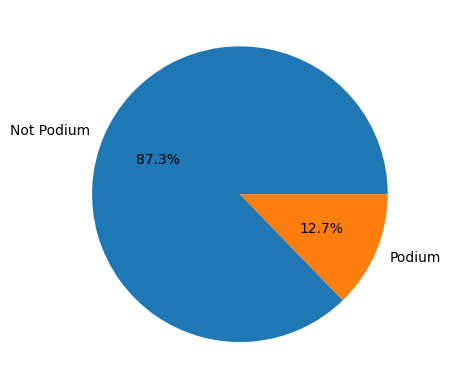

In [13]:
podpie = np.array(df['podium'].value_counts()) # Data
podlabels = ["Not Podium", "Podium"] # Labels
plt.pie(podpie, labels = podlabels, autopct = '%1.1f%%')
plt.show()

The average rate of getting a podium in a race is around `12.7%`.

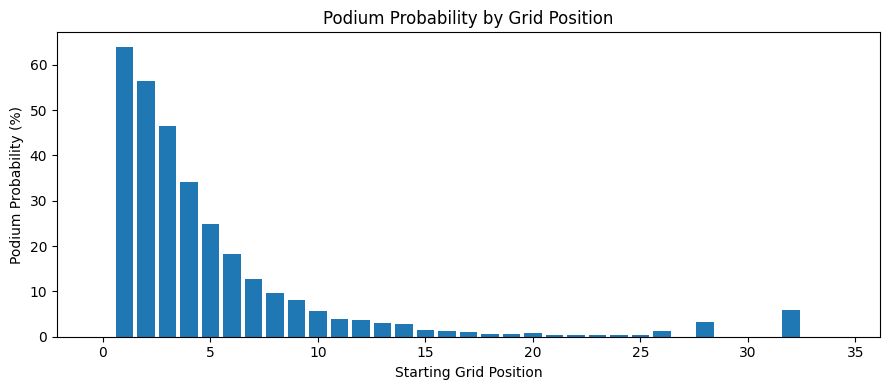

In [14]:
grid_podium = (df.groupby('grid_position')[target].agg(['mean', 'count']).reset_index().rename(columns={'mean': 'podium_rate', 'count': 'races'}))

fig, ax = plt.subplots(figsize = (9, 4))
ax.bar(grid_podium['grid_position'], grid_podium['podium_rate'] * 100)
ax.set_xlabel("Starting Grid Position")
ax.set_ylabel("Podium Probability (%)")
ax.set_title("Podium Probability by Grid Position")
plt.tight_layout()
plt.show()

`Starting grid` above `22` are likely outliers, for now we will ignore it and look at the top where it matters. As we can clearly see, `Starting Grid Position` is **strongly correlated** to the chances of getting a `podium`. *As Grid Position increases, Podium Probability reduces*.

In [15]:
gridpos = np.array(grid_podium['grid_position'])
podrate = np.array(grid_podium['podium_rate'] * 100)
corr, p_value = pearsonr(gridpos, podrate)
print(f"Pearson Correlation Coefficient : {corr}")
print(f"P-Value : {p_value}")

Pearson Correlation Coefficient : -0.6442135845402207
P-Value : 2.9663320459398855e-05


Strengthening the statement before, with a Coefficient of `-0.644` Which indicates a strong negative <br>
relationship and the `P-Value` of less than `0.05`, we can confirm that this is **statistically significant**.

Driver age and their Podium Rates

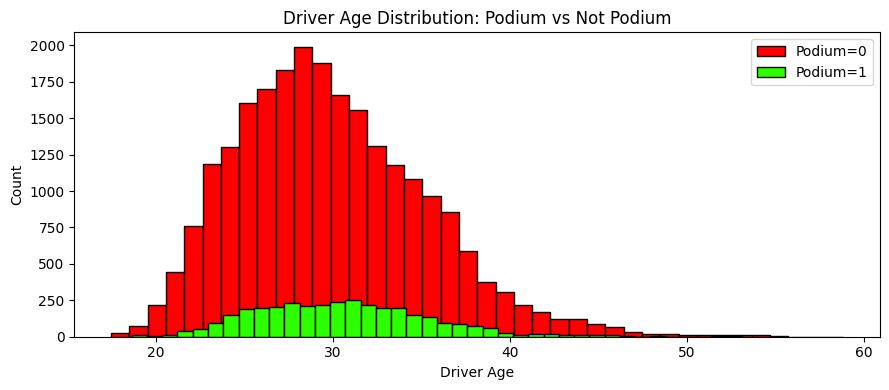

In [16]:
fig, ax = plt.subplots(figsize = (9, 4))
colors = {0: '#FF0000', 1: "#2BFF00"}
for label in [0, 1]:
    ax.hist(df[df[target] == label]['driver_age'].dropna(),bins = 40,label = f'Podium={label}', color = colors[label], edgecolor = 'black')
ax.set_xlabel('Driver Age')
ax.set_ylabel('Count')
ax.set_title('Driver Age Distribution: Podium vs Not Podium')
ax.legend()
plt.tight_layout()
plt.show()

From the graph above, it is shown that young F1 drivers can get podiums up to around `40` years old. From the podium stats, we can see that the prime age of F1 drivers are around `30` where they still have good reflexes and enough experience to get the podium.

Correlation Heatmap (num_col)

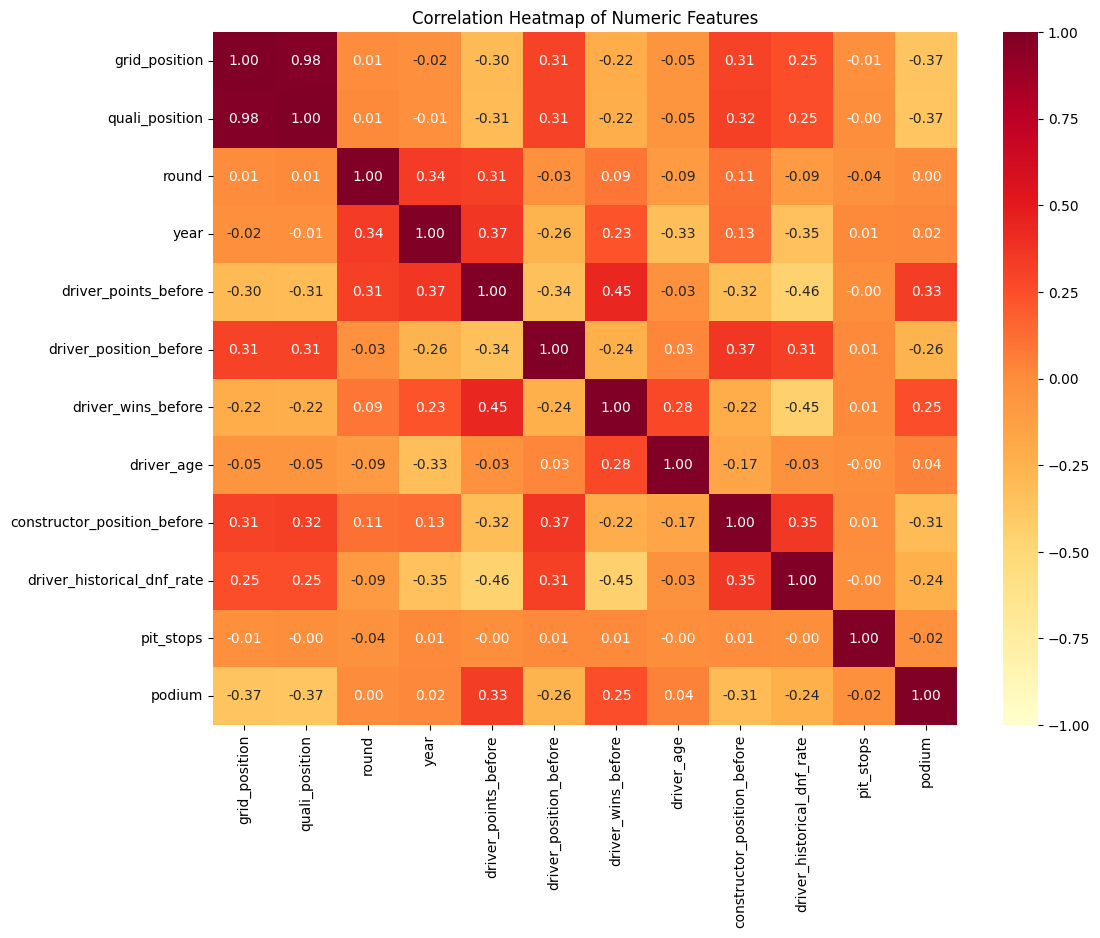

In [ ]:
num_cols = ['grid_position', 'quali_position', 'round', 'year', 'driver_points_before', 'driver_position_before', 'driver_wins_before', 'driver_age', 'constructor_position_before', 'driver_historical_dnf_rate', 'pit_stops', target]
corrnum = df[num_cols].corr()
fig, ax = plt.subplots(figsize = (12, 9))
sns.heatmap(corrnum, annot = True, fmt = '.2f',cmap = 'YlOrRd', ax = ax, vmin = -1, vmax = 1)
ax.set_title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

Heatmap above confirms that `starting position`, `qualifying performance`, and `prior driver success` are the most   
influential factors for podium probability, while things like `driver age`, `pit_stops` plays a much smaller role.

---

# V. Feature Engineering

Train-Test Split

We will be using a `80/20` split between Train and Test.  
`stratify = y` so slass balance stays the same between both.  

In [18]:
X = df.drop(columns=[target]) # Features
y = df[target] # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 94, stratify = y)
print(f"Train size : {X_train.shape[0]}")
print(f"Test size : {X_test.shape[0]}")

Train size : 21843
Test size : 5461


Preprocessing

We will be using `Pipeline` and `ColumnTransformer` to transform numerical and categorical features altogether.

We need to scale the data for numerical features so that features with a high range will not overshadow the features that has low range.  
Also convert catergorical data into numbers so that the model can read it.

In [19]:
num_col = ['grid_position', 'quali_position', 'round', 'year', 'driver_points_before',
                'driver_position_before', 'driver_wins_before', 'driver_age',
                'constructor_position_before', 'driver_historical_dnf_rate',
                'pit_stops']
cat_col = ['driver_nationality', 'constructor_nationality']
            #Pipeline here ensures later that .fit() happens only on training data
num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), # Using median makes sense in terms of F1 because some features like driver points can differ a lot between the field and median is more robust to outliers compared to mean.
                         ('scaler',  StandardScaler())])

cat_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), # Using the mode (most frequent) should be the safest method for categorical column
                         ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]) # Ignore "unknown" features so that it will not crash upon seeing one (example: a new nationality that might not be in the train set)

preprocessor = ColumnTransformer([('num', num_pipeline, num_col),('cat', cat_pipeline, cat_col)]) # Preprocessor

print(f'Numeric : {num_col}')
print(f'Categorical : {cat_col}')

Numeric : ['grid_position', 'quali_position', 'round', 'year', 'driver_points_before', 'driver_position_before', 'driver_wins_before', 'driver_age', 'constructor_position_before', 'driver_historical_dnf_rate', 'pit_stops']
Categorical : ['driver_nationality', 'constructor_nationality']


---

# VI. Model Definition

Models we will attempt to use:
- KNN | Due to it's simplicity this will be our baseline model 
- SVM (Non-Linear (Gaussian (RBF) kernel )) |  It should theoretically be good in high-dimensional space
- Decision Tree | A decent model to be used as a benchmark, is prone to overfitting
- Random Forest | A model that is generally more robust and resistant to overfitting compared to Decision Tree
- XGBoost (Boost Algorithm) | An optimized, scalable version of GBM designed for high performance. It features parallel processing, built-in regularization to prevent overfitting, and handles missing data effectively.

In [20]:
scale_pos = int(y_train.value_counts()[0] / y_train.value_counts()[1])

knn_pipeline = Pipeline([('pre', preprocessor), 
                         ('clf', KNeighborsClassifier())])

svm_pipeline = Pipeline([('pre', preprocessor),
                         ('clf', SVC(probability=True, random_state=94))])

dt_pipeline  = Pipeline([('pre', preprocessor),
                         ('clf', DecisionTreeClassifier(random_state=94))])

rf_pipeline  = Pipeline([('pre', preprocessor),
                         ('clf', RandomForestClassifier(random_state=94))])

xgb_pipeline = Pipeline([('pre', preprocessor),
                         ('clf', XGBClassifier(random_state=94,
                                               scale_pos_weight=scale_pos,
                                               eval_metric='logloss',
                                               verbosity=0))])

pipelines = {'KNN' : knn_pipeline,
             'SVM' : svm_pipeline,
             'Decision Tree' : dt_pipeline,
             'Random Forest' : rf_pipeline,
             'XGBoost' : xgb_pipeline}

---

# VII. Model Training

We will be using `5 fold Cross Validate` because it is the default standard and is considered balanced in effectiveness and computing cost.  

Scoring metrics will be:
- `Weighted F1 score` | Because our data in heavily imbalanced and we would like to minimize both False Positive and False Negative.
- `ROC-AUC` | A scoring metric for imbalanced data
- `Accuracy` | To show why the other metrics are better and set an example of why F1 and ROC_AUC score would be better

In [21]:
cv_result = {}
for modeln, pipeline in pipelines.items():
    print(f"Running 5 fold CV on {modeln}", end= '\n')
    cv_res = cross_validate(pipeline, X_train, y_train,
                            cv = 5,
                            scoring= ['f1_weighted', 'roc_auc', 'accuracy'],
                            n_jobs= -1) # Use all available CPU cores
    cv_result[modeln] = {
        'F1 mean' : cv_res['test_f1_weighted'].mean(), # Average F1 score and take into account class imbalance
        'F1 std' : cv_res['test_f1_weighted'].std(), # To calculate model stability
        'ROC-AUC mean' : cv_res['test_roc_auc'].mean(), # Average quality across folds
        'Accuracy mean' : cv_res['test_accuracy'].mean()} # For reference 

cvdf = pd.DataFrame(cv_result).T
cvdf

Running 5 fold CV on KNN


Running 5 fold CV on SVM
Running 5 fold CV on Decision Tree
Running 5 fold CV on Random Forest
Running 5 fold CV on XGBoost


,F1 mean,F1 std,ROC-AUC mean,Accuracy mean
KNN,0.871464,0.002304,0.834638,0.878771
SVM,0.875533,0.003884,0.851867,0.892780
Decision Tree,0.854093,0.002921,0.676121,0.853179
Random Forest,0.878756,0.001883,0.898517,0.889713
XGBoost,0.869175,0.003547,0.897897,0.856705


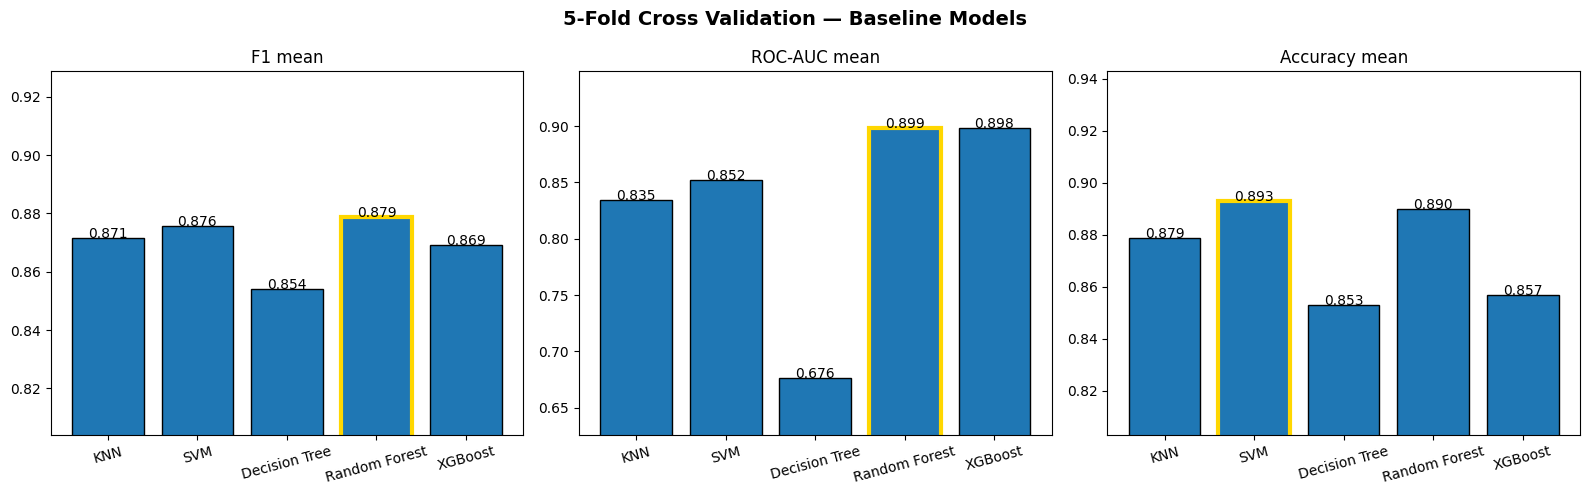

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['F1 mean', 'ROC-AUC mean', 'Accuracy mean']

for ax, metric in zip(axes, metrics):
    vals = cvdf[metric].values
    bars = ax.bar(cvdf.index, vals, edgecolor='black')
    ax.set_title(metric)
    ax.set_xticklabels(cvdf.index, rotation=15)
    ax.set_ylim(min(vals) - 0.05, max(vals) + 0.05) # Makes smaller differences clearer
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2 , bar.get_height(), f'{val:.3f}', ha = 'center')
    bars[np.argmax(vals)].set_edgecolor('gold') # Find and highlight the highest score
    bars[np.argmax(vals)].set_linewidth(3)

plt.suptitle('5-Fold Cross Validation — Baseline Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

From the 3 Bar Chart above, We will obviously take the `Random Forest` model. It shows the highest `F1 Score mean` and `ROC-AUC mean` across 5 folds. Remember that accuracy score here is just for reference and will be misleading due to data imbalance between Podium and Not Podium.

In [23]:
best_model_name = cvdf['F1 mean'].idxmax() # Show index with the highest value
print(f'Best model from Cross Validation : {best_model_name}')
print(f'F1-weighted : {cvdf.loc[best_model_name, "F1 mean"]} +/- {cvdf.loc[best_model_name, "F1 std"]}')
print(f'ROC-AUC : {cvdf.loc[best_model_name, "ROC-AUC mean"]}')

Best model from Cross Validation : Random Forest
F1-weighted : 0.8787561916655322 +/- 0.001882678992548815
ROC-AUC : 0.8985170942239205


Using a code that selects the model with the highest average `F1 score`, we can certainly conclude that `Random Forest` is the best model currently. As a bonus it also has the lowest `standard deviation`.

In [24]:
for model_name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train) # Fit pipelines into Train set

---

# VIII. Model Evaluation

In [25]:
test_results = {}
for modeln, pipeline in pipelines.items():
    y_pred = pipeline.predict(X_test) # Predict target
    y_prob = pipeline.predict_proba(X_test)[:, 1] # Predict probability of class 1 of target (Podium)

    test_results[modeln] = {'Accuracy' : accuracy_score(y_test, y_pred), # Reference only
                            'F1 weighted' : f1_score(y_test, y_pred, average='weighted'),
                            'F1 (podium)' : f1_score(y_test, y_pred, pos_label=1), # Sees how well model can detect minority class (in this case a podium)
                            'ROC-AUC' : roc_auc_score(y_test, y_prob)} # Uses probabilities, not hard predictions

test_df = pd.DataFrame(test_results).T
test_df.sort_values('ROC-AUC', ascending=False)

,Accuracy,F1 weighted,F1 (podium),ROC-AUC
XGBoost,0.855887,0.867987,0.552077,0.897391
Random Forest,0.889214,0.876447,0.452489,0.895161
SVM,0.891412,0.871920,0.404020,0.847664
KNN,0.880242,0.869577,0.435233,0.832355
Decision Tree,0.859183,0.857717,0.434143,0.673310


Since predicting both a podium incorrectly `(FP)` and missing an actual podium `(FN)` have quite a large consequences in the world of Formula 1, we will keep using `F1-score` as the scoring metric. Additionally, `ROC-AUC` is used to evaluate overall classification performance.

For further visualization of that statement, we will use a confusion matrix.

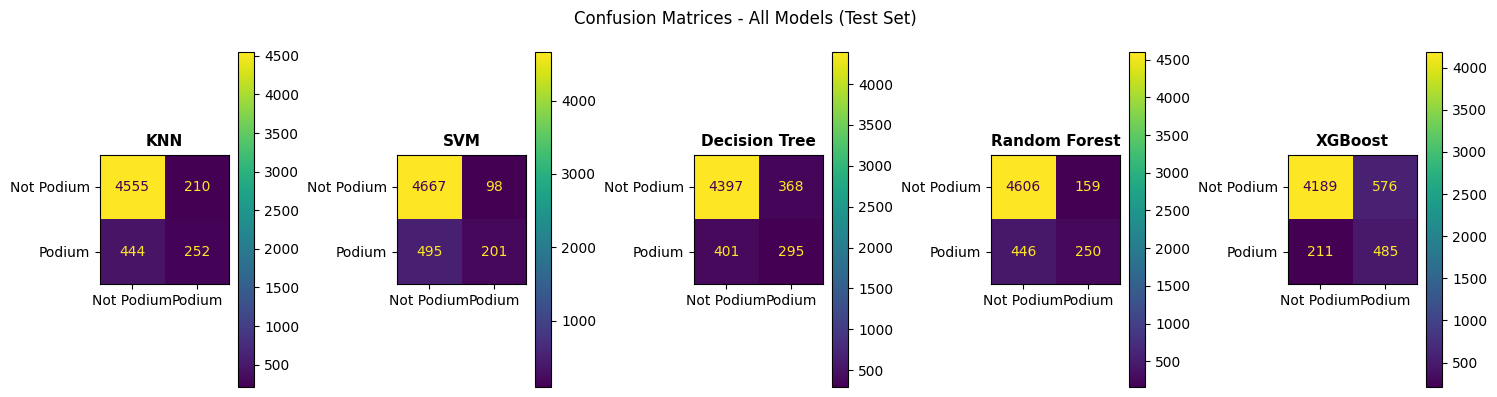

In [26]:
fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for ax, (modeln, pipeline) in zip(axes, pipelines.items()):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, pipeline.predict(X_test)),
        display_labels=['Not Podium', 'Podium']).plot(ax=ax)
    ax.set_title(modeln, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.suptitle('Confusion Matrices - All Models (Test Set)')
plt.tight_layout()
plt.show()

In [27]:
error_summary = {}
for modeln, pipeline in pipelines.items():
    cm = confusion_matrix(y_test, pipeline.predict(X_test))
    fp = cm[0][1] # False Positives
    fn = cm[1][0] # False Negatives
    error_summary[modeln] = {'FP': fp, 'FN': fn, 'FP+FN': fp + fn}

errordf = pd.DataFrame(error_summary).T.astype(int)
errordf

,FP,FN,FP+FN
KNN,210,444,654
SVM,98,495,593
Decision Tree,368,401,769
Random Forest,159,446,605
XGBoost,576,211,787


Looks like `SVM` has the lowest `False Negative` and `False Positive` result out of all the models in the test set. From what we know about Scoring Metrics though, we can infer that the performance of `SVM` in this case can be considered due to **biases** towards the majority of the data (Not Podiums). We will now further analyze the models.

ROC Curves

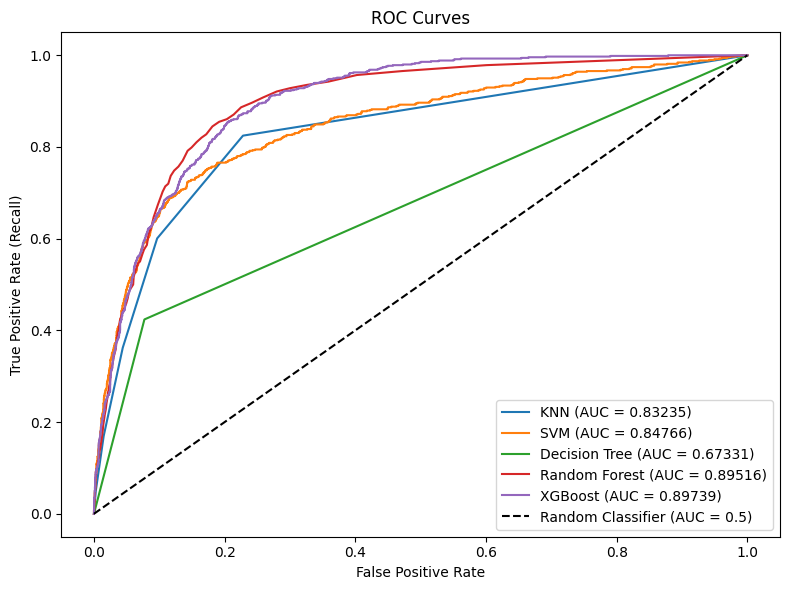

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, pipeline in pipelines.items():
    fpr, tpr, _ = roc_curve(y_test, pipeline.predict_proba(X_test)[:, 1])
    auc = test_df.loc[model_name, 'ROC-AUC']
    ax.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.5f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curves')
ax.legend()
plt.tight_layout()
plt.show()

To choose a model from the graph above, we should know that the best model is the one that curves closest to the top left. Which in this case, is the `Random Forest` model 

In [29]:
print(f"Classification Report {best_model_name} (Test Set)(before tuning):")
roc_auc = test_df.loc[best_model_name, 'ROC-AUC']
print(f"ROC-AUC ({best_model_name}): {roc_auc:.4f}")
print(classification_report(y_test,pipelines[best_model_name].predict(X_test),
                            target_names=['Not Podium', 'Podium']))

Classification Report Random Forest (Test Set)(before tuning):
ROC-AUC (Random Forest): 0.8952
              precision    recall  f1-score   support

  Not Podium       0.91      0.97      0.94      4765
      Podium       0.61      0.36      0.45       696

    accuracy                           0.89      5461
   macro avg       0.76      0.66      0.70      5461
weighted avg       0.87      0.89      0.88      5461



The current best model is the `Random Forest` model. So we will use this model in `Hyperparameter Tuning` to see if we can make it better.

---

# IX. Hyperparameter Tuning

Here, changing the `hyperparameters` may result in a better model. We will be using `RandomizedSearchCV` instead of `GridSearchCV` because `RandomSearch` uses much **less computing** power compared to `GridSearch` yet yields a result not too significantly inferior to it.

In [30]:
tuning_pipeline = pipelines[best_model_name]

params = {'Random Forest': {
    'clf__n_estimators' : [100, 200, 300], # Amount of trees
    'clf__max_depth' : [None, 10, 20], # Depth control
    'clf__min_samples_split' : [2, 5, 10], # Min samples to split
    'clf__max_features' : ['sqrt', 'log2']}} # Features considered per split 

randscv = RandomizedSearchCV(
    estimator = tuning_pipeline,
    param_distributions = params[best_model_name],
    n_iter = 20 , # 20 random combinations
    cv     = 5 , # Same CV strategy as before
    scoring= 'f1_weighted' , # Same primary metric as before
    n_jobs = -1 ,# Use all CPU cores
    random_state = 94, # Make it reproducible
    verbose= 1
)

randscv.fit(X_train, y_train)
print(f"Best params: {randscv.best_params_}")
print(f"Best F1 (weighted) ({best_model_name}): {randscv.best_score_}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'clf__n_estimators': 200, 'clf__min_samples_split': 10, 'clf__max_features': 'sqrt', 'clf__max_depth': None}
Best F1 (weighted) (Random Forest): 0.8819887358813829


After doing the `RandomSearchCV`, the best parameters were `{'clf__n_estimators': 200, 'clf__min_samples_split': 10, 'clf__max_features': 'sqrt', 'clf__max_depth': None}` and the ROC-AUC score increased. Do note that F1 (weighted) here may differ from the data after this cell because this score is obtained during the tuning process.

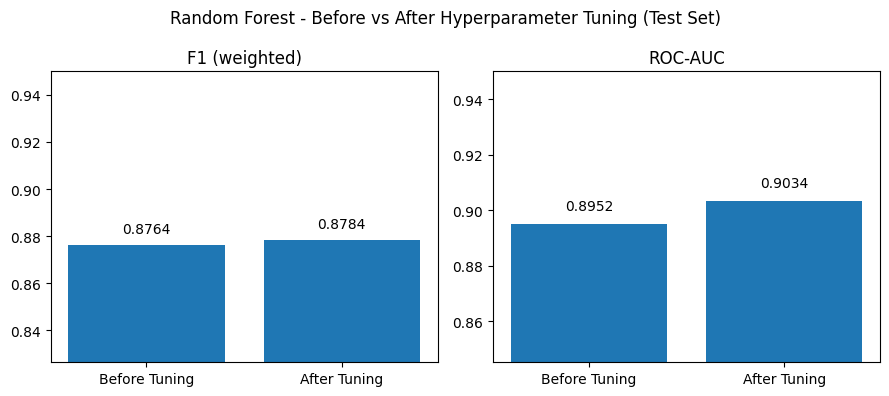

F1 Score before: 0.8764 | ROC-AUC: 0.8952
F1 Score after: 0.8784 | ROC-AUC: 0.9034

Classification Report Random Forest (After Tuning):
              precision    recall  f1-score   support

  Not Podium       0.91      0.97      0.94      4765
      Podium       0.64      0.35      0.45       696

    accuracy                           0.89      5461
   macro avg       0.78      0.66      0.70      5461
weighted avg       0.88      0.89      0.88      5461



In [31]:
tuned_pred = randscv.best_estimator_.predict(X_test) 
tuned_prob = randscv.best_estimator_.predict_proba(X_test)[:, 1] # Predict probability of podium
f1_after   = f1_score(y_test, tuned_pred, average='weighted')
auc_after  = roc_auc_score(y_test, tuned_prob)

f1_before  = test_df.loc[best_model_name, 'F1 weighted']
auc_before = test_df.loc[best_model_name, 'ROC-AUC']

compare_df = pd.DataFrame({'Stage' : ['Before Tuning', 'After Tuning'],
                           'F1 (weighted)' : [f1_before, f1_after],
                           'ROC-AUC' : [auc_before, auc_after]})

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, col in zip(axes, ['F1 (weighted)', 'ROC-AUC']):
    bars = ax.bar(compare_df['Stage'], compare_df[col])
    ax.set_ylim(min(compare_df[col]) - 0.05, 0.95)
    ax.set_title(col)
    for bar, val in zip(bars, compare_df[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center')

plt.suptitle(f"{best_model_name} - Before vs After Hyperparameter Tuning (Test Set)")
plt.tight_layout()
plt.show()

print(f"F1 Score before: {f1_before:.4f} | ROC-AUC: {auc_before:.4f}")
print(f"F1 Score after: {f1_after:.4f} | ROC-AUC: {auc_after:.4f}")
print()
print(f"Classification Report {best_model_name} (After Tuning):")
print(classification_report(y_test, tuned_pred, target_names=['Not Podium', 'Podium']))

The tuned `Random Forest` model showed an **improvement** within `F1 (weighted)` score and `ROC-AUC` compared to before.

Now, I will attempt to check the importances of each features. (This will make sense later)

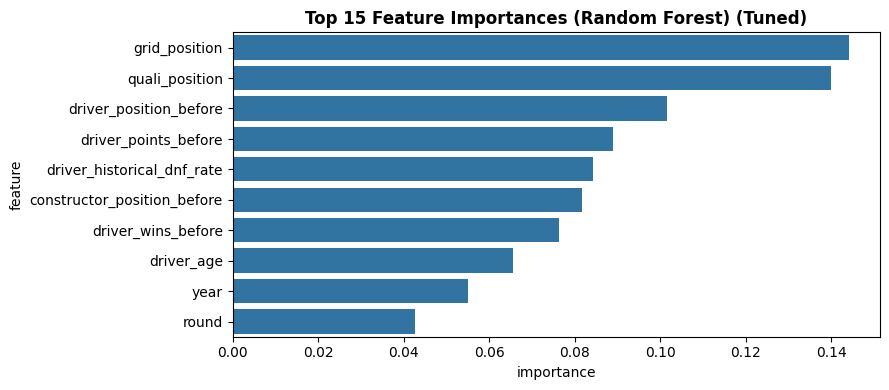

In [32]:
best_model = randscv.best_estimator_

cat_names = best_model.named_steps['pre'] \
    .named_transformers_['cat'] \
    .named_steps['encoder'] \
    .get_feature_names_out(cat_col)
feature_names = num_col + list(cat_names)

importances = best_model.named_steps['clf'].feature_importances_

feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(9, 4))
sns.barplot(data=feat_imp, x='importance', y='feature')
plt.title(f'Top 15 Feature Importances ({best_model_name}) (Tuned)', fontweight='bold')
plt.tight_layout()
plt.show()

Confirming what we generally know and from the Heatmap in the `EDA` section:
- `grid position` and `quali position` (arguably the same) matters the most on getting a podium. 
- Their `championship position` and `points` also matters because it does reflect how they did before that race. 
- Both `historical dnf rate` and `driver wins before` also reflects the driver's history. 
- As stated before as well, `driver's age` also matters albeit by an insignificant margin, same goes to year and round.

---

# X. Model Saving

In [33]:
df.to_csv('f1df.csv', index=False) # Save csv
joblib.dump(randscv.best_estimator_, 'best_model.pkl') # Save model
driver_nats = sorted(df['driver_nationality'].dropna().unique().tolist()) # Driver Nationality
constructor_nats = sorted(df['constructor_nationality'].dropna().unique().tolist()) # Constructor Nationality
nationality_data = {"driver_nationalities" : driver_nats,
                    "constructor_nationalities" : constructor_nats}
with open('nationalities.txt', 'w') as file_1:
  json.dump(nationality_data, file_1)

---

# XI. Model Inference

Will be done in [HuggingFace](https://huggingface.co/spaces/StefVero/M2) and inference notebook

---

# XII. Conclusion

## Problem Statement

Predict podium winner in Formula 1

## Objective

Create a Machine Learning Program that predicts F1 Podiums based on several features where the results can help Teams and Sponsors decide on their next business decision.

## EDA Findings

- As the name suggests, a podium rate per race is only around 12.7% across the history of Formula 1.
- Higher starting grid position means higher chance of a podium.
- Driver results in general peaked at around 30 years of age.
- Historical DNF rate somewhat matters although not by much.

## Possible Improvements

- Use different features that are more important to the model (for example: keep the top 5 most important features here and replace the rest with another feature that may have more significance on the model).
- Filter to post 2011 data for a cleaner overall data.
- Use regulation periods for a more realistic model.
- Apply SMOTE (Podium is very imbalanced)

---